# Prova - Extração e Análise de Dados (Resolução)

- Q1: Limpeza de e-mails
- Q2: API de Biblioteca (FastAPI)
- Q3: PCA e K-Means para influenciadores
- Q4: Análise de E-commerce
- Q5: Análise de Notas Escolares
- Q6: Extra - Raspagem


## Q1 - Limpeza de e-mails


In [ ]:
# Questão 1 - Limpeza de Dados de Texto
# Objetivo: limpar a lista de e-mails removendo espaços extras e
#           deixando tudo em letras minúsculas.
# Dica: usar os métodos de string .strip() e .lower()
#       e percorrer a lista com um for (ou list comprehension).

# Lista original 
emails_clientes = [
    '   joao.silva@gmail.com   ',
    '  MARIA.SANTOS@HOTMAIL.COM  ',
    '     pedro_costa@yahoo.com.br     ',
    '  ANA.OLIVEIRA@OUTLOOK.COM   ',
    '    carlos123@empresa.com.br   '
]

# Minha solução (versão com for):
emails_limpos = []  # lista vazia para guardar os e-mails já limpos
for email in emails_clientes:
    # .strip() tira espaços do começo e do fim
    # .lower() transforma todas as letras em minúsculas
    email_limpo = email.strip().lower()
    emails_limpos.append(email_limpo)

# Se preferir, também dá para fazer com list comprehension (apenas como referência):
# emails_limpos = [e.strip().lower() for e in emails_clientes]

# Mostrando o resultado final
print("E-mails limpos:")
for email in emails_limpos:
    print(email)



E-mails limpos:
joao.silva@gmail.com
maria.santos@hotmail.com
pedro_costa@yahoo.com.br
ana.oliveira@outlook.com
carlos123@empresa.com.br


## Q2 - API de Biblioteca (FastAPI)
Código comentado. Para testar a API, execute localmente com `uvicorn` (instruções ao final da célula).


In [ ]:
from fastapi import FastAPI
from typing import Optional, List, Dict, Any

app = FastAPI(title="Biblioteca Digital API", version="1.0.0")

livros_db: List[Dict[str, Any]] = [
    {"id": 1, "titulo": "1984", "autor": "George Orwell", "ano": 1949, "paginas": 328, "genero": "Ficção Científica", "disponivel": True},
    {"id": 2, "titulo": "Dom Casmurro", "autor": "Machado de Assis", "ano": 1899, "paginas": 256, "genero": "Romance", "disponivel": False},
    {"id": 3, "titulo": "O Pequeno Príncipe", "autor": "Antoine de Saint-Exupéry", "ano": 1943, "paginas": 96, "genero": "Fábula", "disponivel": True},
    {"id": 4, "titulo": "Cem Anos de Solidão", "autor": "Gabriel García Márquez", "ano": 1967, "paginas": 417, "genero": "Realismo Mágico", "disponivel": True},
    {"id": 5, "titulo": "Fahrenheit 451", "autor": "Ray Bradbury", "ano": 1953, "paginas": 249, "genero": "Ficção Científica", "disponivel": False},
    {"id": 6, "titulo": "O Cortiço", "autor": "Aluísio Azevedo", "ano": 1890, "paginas": 304, "genero": "Naturalismo", "disponivel": True},
    {"id": 7, "titulo": "Hypnerotomachia Poliphili", "autor": "Francesco Colonna", "ano": 1499, "paginas": 700, "genero": "Ficção", "disponivel": False},
]

@app.get("/biblioteca/info")
def info_biblioteca() -> Dict[str, Any]:
    total = len(livros_db)
    resposta = {
        "nome": "Biblioteca Digital FGV Comunicação Rio",
        "total_livros": total,
        "mensagem": "Bem-vindo à nossa biblioteca digital!",
    }
    return resposta

@app.get("/biblioteca/livro/{livro_id}")
def buscar_livro(livro_id: int) -> Dict[str, Any]:
    for livro in livros_db:
        if livro.get("id") == livro_id: # Aqui poderia ser livro['id'], é a mesma coisa!
            return livro
    return {"erro": f"Livro com ID {livro_id} não encontrado"}

# Instrução:
# Rodar localmente com: uvicorn prova_resolucao:app --reload  (a partir desta pasta)
# Nota: Em alguns ambientes de notebook, rodar FastAPI direto não é ideal; use terminal.



## Q3 - PCA e K-Means (Influenciadores)
Código com impressões, gráficos e interpretações simples.


-- Base de influenciadores criada!
Total: 180 influenciadores
  PlataformaPrincipal NomeInfluencer  TaxaEngajamento  PostsPorSemana  \
0           Instagram   @creator_001              5.2               6   
1           Instagram   @creator_002              4.1               5   
2           Instagram   @creator_003              3.0               3   
3           Instagram   @creator_004              3.0               4   
4           Instagram   @creator_005              4.3               5   

   PontuacaoAutenticidade  DiversidadeConteudo  IndiceConversao  
0                     5.7                  7.8               37  
1                     9.1                  8.0                5  
2                     7.4                  4.5               35  
3                     6.5                  7.5               24  
4                     5.9                  6.2               11  

=== Etapa 1: Análise descritiva por plataforma ===
                     TaxaEngajamento  PostsPorSeman

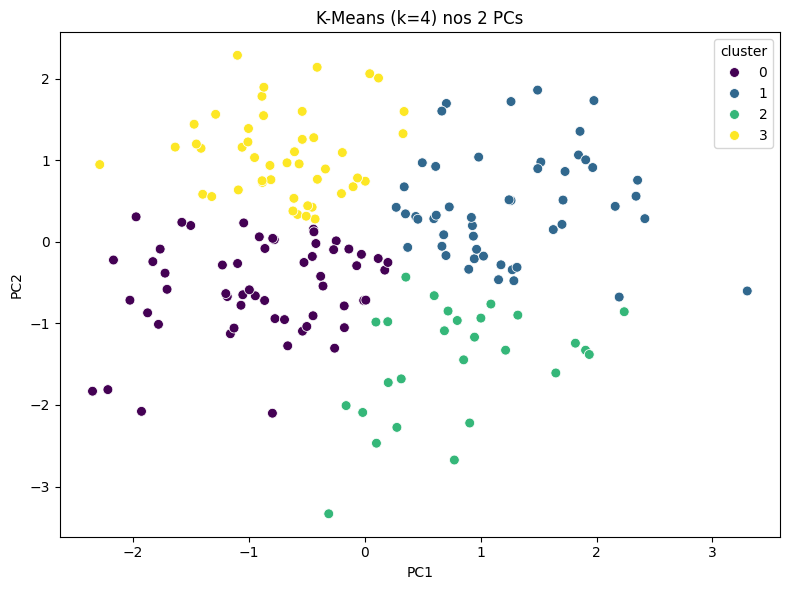


=== Etapa 5: Caracterização dos clusters ===
Médias por cluster (nas variáveis originais):
         TaxaEngajamento  PostsPorSemana  DiversidadeConteudo  \
cluster                                                         
0                   2.61            5.16                 5.64   
1                   5.25           10.86                 7.09   
2                   4.14           13.30                 4.70   
3                   2.93            2.93                 8.07   

         PontuacaoAutenticidade  IndiceConversao  
cluster                                           
0                          6.82            33.77  
1                          8.22            19.16  
2                          6.20            26.74  
3                          8.09            25.85  

Distribuição de plataformas por cluster:
PlataformaPrincipal  Instagram  LinkedIn  TikTok  Twitter  YouTube
cluster                                                           
0                           21     

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')
sns.set_palette("viridis")

np.random.seed(2024)

plataformas = ['Instagram', 'TikTok', 'YouTube', 'Twitter', 'LinkedIn']
n_influencers_por_plataforma = [50, 45, 35, 30, 20]

lista_plataformas = []
for plataforma, n in zip(plataformas, n_influencers_por_plataforma):
    lista_plataformas.extend([plataforma] * n)

total_influencers = len(lista_plataformas)

engajamento_base = {'Instagram': 3.2, 'TikTok': 5.8, 'YouTube': 2.1, 'Twitter': 1.8, 'LinkedIn': 4.5}
posts_base = {'Instagram': 6, 'TikTok': 12, 'YouTube': 2, 'Twitter': 15, 'LinkedIn': 4}
autenticidade_base = {'Instagram': 6.5, 'TikTok': 7.8, 'YouTube': 8.2, 'Twitter': 7.0, 'LinkedIn': 8.5}

df_influencers = pd.DataFrame({
    'PlataformaPrincipal': lista_plataformas,
    'NomeInfluencer': [f'@creator_{i+1:03d}' for i in range(total_influencers)],
})

df_influencers['TaxaEngajamento'] = [np.random.normal(engajamento_base[plat], 1.2) for plat in df_influencers['PlataformaPrincipal']]
df_influencers['PostsPorSemana'] = [np.random.normal(posts_base[plat], 3) for plat in df_influencers['PlataformaPrincipal']]
df_influencers['PontuacaoAutenticidade'] = [np.random.normal(autenticidade_base[plat], 1.5) for plat in df_influencers['PlataformaPrincipal']]
df_influencers['DiversidadeConteudo'] = np.random.normal(6.5, 2.0, total_influencers)
df_influencers['IndiceConversao'] = np.random.normal(25, 15, total_influencers)

df_influencers['TaxaEngajamento'] = np.clip(df_influencers['TaxaEngajamento'], 0.5, 12.0).round(1)
df_influencers['PostsPorSemana'] = np.clip(df_influencers['PostsPorSemana'], 1, 25).astype(int)
df_influencers['DiversidadeConteudo'] = np.clip(df_influencers['DiversidadeConteudo'], 1, 10).round(1)
df_influencers['PontuacaoAutenticidade'] = np.clip(df_influencers['PontuacaoAutenticidade'], 1, 10).round(1)
df_influencers['IndiceConversao'] = np.clip(df_influencers['IndiceConversao'], 5, 80).astype(int)

print("-- Base de influenciadores criada!")
print(f"Total: {len(df_influencers)} influenciadores")
print(df_influencers.head())

print("\n=== Etapa 1: Análise descritiva por plataforma ===")
cols_numericas = [
    'TaxaEngajamento', 'PostsPorSemana', 'DiversidadeConteudo',
    'PontuacaoAutenticidade', 'IndiceConversao'
]

grp = df_influencers.groupby('PlataformaPrincipal')[cols_numericas].mean().round(2)
print(grp)

print("\nAlguns insights:")
print("- Plataforma com maior engajamento médio:", grp['TaxaEngajamento'].idxmax(), grp['TaxaEngajamento'].max())
print("- Plataforma com mais posts por semana:", grp['PostsPorSemana'].idxmax(), grp['PostsPorSemana'].max())
print("- Plataforma com maior autenticidade média:", grp['PontuacaoAutenticidade'].idxmax(), grp['PontuacaoAutenticidade'].max())

print("\n=== Etapa 2: Padronização dos dados ===")
print("Antes (amostra):")
print(df_influencers[cols_numericas].head())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_influencers[cols_numericas])

print("Depois (amostra):")
print(pd.DataFrame(X_scaled, columns=cols_numericas).head())

print("\n=== Etapa 3: PCA com 2 componentes ===")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_total = pca.explained_variance_ratio_.sum()
print(f"Variância total explicada (PC1 + PC2): {var_total:.2f}")
print("Componentes (loadings):")
loadings = pd.DataFrame(pca.components_, columns=cols_numericas, index=['PC1', 'PC2']).round(2)
print(loadings)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print("\n=== Etapa 4: K-Means com k=4 ===")
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_pca)

df_resultado = df_influencers.copy()
df_resultado['PC1'] = df_pca['PC1']
df_resultado['PC2'] = df_pca['PC2']
df_resultado['cluster'] = clusters

print("Centróides (no espaço dos PCs):")
print(pd.DataFrame(kmeans.cluster_centers_, columns=['PC1','PC2']).round(2))

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_resultado, x='PC1', y='PC2', hue='cluster', palette='viridis', s=50)
plt.title('K-Means (k=4) nos 2 PCs')
plt.legend(title='cluster')
plt.tight_layout()
plt.show()

print("\n=== Etapa 5: Caracterização dos clusters ===")
caracteristicas = df_resultado.groupby('cluster')[cols_numericas].mean().round(2)
print("Médias por cluster (nas variáveis originais):")
print(caracteristicas)

print("\nDistribuição de plataformas por cluster:")
print(df_resultado.groupby(['cluster','PlataformaPrincipal']).size().unstack(fill_value=0))

medias_globais = df_influencers[cols_numericas].mean()
nomes_clusters = {}
for c in sorted(df_resultado['cluster'].unique()):
    linha = caracteristicas.loc[c]
    nome = []
    if linha['PostsPorSemana'] > medias_globais['PostsPorSemana']:
        nome.append('Alta Frequência')
    if linha['TaxaEngajamento'] > medias_globais['TaxaEngajamento']:
        nome.append('Engajados')
    if linha['PontuacaoAutenticidade'] > medias_globais['PontuacaoAutenticidade']:
        nome.append('Autênticos')
    if linha['IndiceConversao'] > medias_globais['IndiceConversao']:
        nome.append('Conversores')
    if len(nome) == 0:
        nome = ['Equilibrados']
    nomes_clusters[c] = " / ".join(nome)

print("\nSugestão de nomes para os arquétipos:")
for c, n in nomes_clusters.items():
    print(f"- Cluster {c}: {n}")

print("\nInterpretação (exemplo):")
print("- PC1 e PC2 parecem combinar engajamento, frequência e autenticidade em direções diferentes.")
print("- Os clusters mostram grupos com perfis distintos (ex.: mais posts e engajamento, ou mais conversão).")
print("- Uma marca pode escolher clusters com mais 'Engajados' para awareness ou 'Conversores' para performance.")



## Q4 - Análise de E-commerce
Itens A, B e C com limpeza, agregações e filtros.


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

np.random.seed(42)

n_vendas = 800
categorias = ['Eletrônicos', 'Roupas', 'Casa', 'Livros', 'Esporte']
canais = ['Online', 'Loja Física', 'App Mobile', 'Telefone']
cidades = ['São Paulo', 'Rio de Janeiro', 'Belo Horizonte', 'Curitiba', 'Salvador']

df_vendas = pd.DataFrame({
    'id_venda': range(1, n_vendas + 1),
    'categoria_produto': np.random.choice(categorias, n_vendas),
    'canal_venda': np.random.choice(canais, n_vendas),
    'cidade': np.random.choice(cidades, n_vendas),
    'qtd_vendida': np.random.randint(1, 10, n_vendas),
    'preco_unit': np.round(np.random.normal(150, 80, n_vendas), 2),
    'data_venda': [datetime(2024, 1, 1) + timedelta(days=int(x)) for x in np.random.randint(0, 365, n_vendas)],
    'satisfacao_cliente': np.round(np.random.normal(4.2, 0.8, n_vendas), 1),
    'tempo_entrega': np.random.randint(1, 15, n_vendas)
})

df_vendas['preco_unit'] = df_vendas['preco_unit'].clip(10, 500)
df_vendas['satisfacao_cliente'] = df_vendas['satisfacao_cliente'].clip(1.0, 5.0)

df_vendas['valor_total'] = df_vendas['qtd_vendida'] * df_vendas['preco_unit']

mask_nan = np.random.choice([True, False], size=len(df_vendas), p=[0.03, 0.97])
df_vendas.loc[mask_nan, 'satisfacao_cliente'] = np.nan

print("📦 Base de vendas criada!")
print(f"Total de registros: {len(df_vendas)}")
print(df_vendas.head())

print("\n=== Item A: Limpeza e Preparação ===")
faltando = df_vendas['satisfacao_cliente'].isna().sum()
print("A1 - Valores ausentes em satisfacao_cliente:", faltando)

medianas_por_cat = df_vendas.groupby('categoria_produto')['satisfacao_cliente'].median()
medianas_por_cat_map = df_vendas['categoria_produto'].map(medianas_por_cat)
df_vendas['satisfacao_cliente'] = df_vendas['satisfacao_cliente'].fillna(medianas_por_cat_map)

renomear = {
    'categoria_produto': 'product_category',
    'canal_venda': 'sales_channel',
    'qtd_vendida': 'quantity_sold',
    'preco_unit': 'unit_price',
    'data_venda': 'sale_date',
    'satisfacao_cliente': 'customer_satisfaction',
    'tempo_entrega': 'delivery_time'
}
df = df_vendas.rename(columns=renomear).copy()

print("Colunas após renomear:")
print(df.columns.tolist())

print("\n=== Item B: Análise por Categoria ===")
agr = df.groupby('product_category').agg(
    total_vendas=('id_venda', 'count'),
    valor_total_vendido=('valor_total', 'sum'),
    ticket_medio=('valor_total', 'mean'),
    satisfacao_media=('customer_satisfaction', 'mean'),
    tempo_medio_entrega=('delivery_time', 'mean')
).round(2)
print(agr)

agr_ordenado = agr.sort_values('valor_total_vendido', ascending=False)
print("\nOrdenado por valor_total_vendido (desc):")
print(agr_ordenado)

melhor_cat = agr['satisfacao_media'].idxmax()
pior_cat = agr['satisfacao_media'].idxmin()
print(f"\nMelhor satisfação: {melhor_cat} -> {agr.loc[melhor_cat, 'satisfacao_media']:.2f}")
print(f"Pior satisfação: {pior_cat} -> {agr.loc[pior_cat, 'satisfacao_media']:.2f}")

print("\nInsights rápidos (exemplo):")
print("- Categoria com maior receita ajuda a priorizar campanhas de marketing.")
print("- Ticket médio mostra onde clientes gastam mais por compra.")
print("- Satisfação e entrega podem indicar foco em melhoria operacional.")

print("\n=== Item C: Canal e Filtros ===")
pivot = pd.pivot_table(
    df,
    index='sales_channel',
    columns='product_category',
    values='valor_total',
    aggfunc='sum',
    fill_value=0
)
print("Tabela pivot (soma de valor_total):")
print(pivot)

filtro = (
    (df['valor_total'] > 200) &
    (df['customer_satisfaction'] >= 4.0) &
    (df['delivery_time'] <= 7)
)
df_premium = df.loc[filtro].copy()

colunas_c3 = ['id_venda', 'product_category', 'sales_channel', 'valor_total', 'customer_satisfaction']
resultado_c3 = df_premium[colunas_c3]
print("\nVendas premium (amostra):")
print(resultado_c3.head())

canal_melhor = pivot.sum(axis=1).idxmax()
qtd_premium = len(resultado_c3)
print(f"\nCanal com melhor desempenho (soma receita): {canal_melhor}")
print(f"Quantidade de vendas premium: {qtd_premium}")

print("\nComo isso ajuda a empresa?")
print("- Focar no canal com maior receita para campanhas.")
print("- Usar vendas premium para entender perfil de clientes de alto valor.")



📦 Base de vendas criada!
Total de registros: 800
   id_venda categoria_produto  canal_venda          cidade  qtd_vendida  \
0         1            Livros   App Mobile       São Paulo            9   
1         2           Esporte   App Mobile  Belo Horizonte            9   
2         3              Casa   App Mobile        Curitiba            1   
3         4           Esporte   App Mobile        Curitiba            3   
4         5           Esporte  Loja Física        Salvador            4   

   preco_unit data_venda  satisfacao_cliente  tempo_entrega  valor_total  
0      248.11 2024-08-09                 3.9              8      2232.99  
1      242.57 2024-03-01                 3.1              2      2183.13  
2      244.09 2024-05-08                 3.6              4       244.09  
3       11.28 2024-06-21                 5.0             14        33.84  
4      166.54 2024-06-04                 4.9              3       666.16  

=== Item A: Limpeza e Preparação ===
A1 - Valores

## Q5 - Análise de Notas Escolares
Médias, status, análise por turma e relatório de risco.


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(123)

alunos_data = {
    'nome': ['Ana S.', 'Bruno C.', 'Carla S.', 'Diego O.', 'Elena R.',
             'Felipe L.', 'Gabriela S.', 'Henrique A.', 'Isabela F.', 'João P.',
             'Larissa M.', 'Marcos V.', 'Natália C.', 'Otávio R.', 'Patrícia G.',
             'Rafael B.', 'Sofia R.', 'Thiago N.', 'Vitória C.', 'Wellington T.'],
    'turma': ['A', 'A', 'B', 'A', 'B', 'C', 'B', 'C', 'A', 'B',
              'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C'],
    'matematica': [8.5, 7.2, 9.1, 6.8, 8.9, 7.5, 8.0, 6.3, 9.5, 7.8,
                   8.2, 6.9, 8.7, 7.1, 9.0, 7.6, 8.4, 6.5, 8.8, 7.3],
    'portugues': [9.0, 6.8, 8.5, 7.2, 9.2, 6.9, 8.1, 7.4, 9.3, 8.0,
                  7.7, 7.0, 8.9, 6.6, 8.8, 7.5, 8.3, 6.8, 9.1, 7.2],
    'ciencias': [7.8, 8.1, 9.0, 7.5, 8.6, 7.9, 8.3, 7.0, 9.2, 8.4,
                 8.0, 7.6, 8.5, 7.3, 8.9, 8.2, 8.1, 7.1, 8.7, 7.8],
    'faltas': [2, 8, 1, 12, 3, 15, 4, 18, 0, 6,
               5, 14, 2, 16, 1, 7, 3, 13, 2, 9]
}

df_notas = pd.DataFrame(alunos_data)
print("📚 Base de notas criada!")
print(f"Total de alunos: {len(df_notas)}")
print(df_notas.head())

print("\n=== Item A: Média geral ===")
cols = ['matematica', 'portugues', 'ciencias']
df_notas['media_geral'] = df_notas[cols].mean(axis=1).round(2)

idx_maior = df_notas['media_geral'].idxmax()
idx_menor = df_notas['media_geral'].idxmin()
print("Maior média:", df_notas.loc[idx_maior, 'nome'], df_notas.loc[idx_maior, 'media_geral'])
print("Menor média:", df_notas.loc[idx_menor, 'nome'], df_notas.loc[idx_menor, 'media_geral'])

print("\n=== Item B: Status ===")

def classificar_status(media, faltas):
    if (media >= 7.0) and (faltas <= 10):
        return "Aprovado"
    elif (media >= 6.0) and (media < 7.0) and (faltas <= 15):
        return "Recuperação"
    else:
        return "Reprovado"

df_notas['status'] = df_notas.apply(lambda r: classificar_status(r['media_geral'], r['faltas']), axis=1)

contagem_status = df_notas['status'].value_counts()
print("Contagem por status:")
print(contagem_status)

print("\n=== Item C: Análise por Turma ===")
agr_turma = df_notas.groupby('turma').agg(
    media_geral_turma=('media_geral', 'mean'),
    total_alunos=('nome', 'count'),
    aprovados=('status', lambda s: (s == 'Aprovado').sum()),
    faltas_medias=('faltas', 'mean')
).round(2)
print(agr_turma)

melhor_turma = agr_turma['media_geral_turma'].idxmax()
print("Turma com melhor desempenho:", melhor_turma)

print("\n=== Item D: Alunos em risco ===")
risco = df_notas[df_notas['status'].isin(['Reprovado', 'Recuperação'])].copy()
colunas_rel = ['nome', 'turma', 'media_geral', 'faltas', 'status']
relatorio_risco = risco[colunas_rel].sort_values('media_geral')
print(relatorio_risco)

print("\nInterpretação final (exemplo):")
print(f"- Melhor turma: {melhor_turma}.")
print(f"- Alunos que precisam de atenção: {len(relatorio_risco)}.")
correlacao_faltas_media = round(df_notas[['faltas', 'media_geral']].corr().loc['faltas', 'media_geral'], 2)
print(f"- Correlação (faltas x média_geral): {correlacao_faltas_media}")



📚 Base de notas criada!
Total de alunos: 20
       nome turma  matematica  portugues  ciencias  faltas
0    Ana S.     A         8.5        9.0       7.8       2
1  Bruno C.     A         7.2        6.8       8.1       8
2  Carla S.     B         9.1        8.5       9.0       1
3  Diego O.     A         6.8        7.2       7.5      12
4  Elena R.     B         8.9        9.2       8.6       3

=== Item A: Média geral ===
Maior média: Isabela F. 9.33
Menor média: Thiago N. 6.8

=== Item B: Status ===
Contagem por status:
status
Aprovado       14
Reprovado       5
Recuperação     1
Name: count, dtype: int64

=== Item C: Análise por Turma ===
       media_geral_turma  total_alunos  aprovados  faltas_medias
turma                                                           
A                   7.88             7          4           7.14
B                   8.47             7          7           3.57
C                   7.50             6          3          11.00
Turma com melhor desempen

## Q6 – EXTRA – Raspagem
Identificação das combinações (tag + classe) para módulos e funções/classes no índice da API do Scikit-learn.


In [6]:
# Questão 6 – EXTRA – Raspagem
print({'categoria': 'modulos', 'tag': 'li', 'classe': 'toctree-l1'})
print({'categoria': 'funcoes/classes', 'tag': 'li', 'classe': 'toctree-l2'})

{'categoria': 'modulos', 'tag': 'li', 'classe': 'toctree-l1'}
{'categoria': 'funcoes/classes', 'tag': 'li', 'classe': 'toctree-l2'}
